# SAM + CNN

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Downloading the SAM ViT model

# !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [1]:
# !pip install opencv-python matplotlib

# Clone and install SAM
# !pip install git+https://github.com/facebookresearch/segment-anything.git

In [ ]:
import numpy as np
from PIL import Image
from pathlib import Path

import cv2                 # OpenCV for image processing
import torch               # Core PyTorch library for tensor operations and deep learning

import torch.nn as nn                          # Neural network layers and modules
import torch.optim as optim                    # Optimizers like Adam, SGD for training
from torchvision import transforms, datasets  # Common image transforms and dataset utilities
from torch.utils.data import DataLoader       # Data loader for batching and shuffling datasets

import matplotlib.pyplot as plt
import matplotlib.patches as patches           # For drawing bounding boxes on images

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator # Facebook's SAM for automatic mask generation

import os
import json
from tqdm import tqdm

In [ ]:
# Initializing the SAM Mask generator

sam_checkpoint = "sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to("cuda" if torch.cuda.is_available() else "cpu")
mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
def load_annotations(json_paths):
    '''
    Function to load the annotations from json file. These annotations contain fields like bounding box, segment, item id, etc.
    '''
    all_anns = {}
    category_map = {}
    for path in json_paths:
        with open(path) as f:
            coco = json.load(f)
        image_id_to_filename = {img['id']: img['file_name'] for img in coco['images']}
        category_map.update({cat['id']: cat['name'] for cat in coco['categories']})
        for ann in coco['annotations']:
            img_id = ann['image_id']
            if img_id not in all_anns:
                all_anns[img_id] = {'file_name': image_id_to_filename[img_id], 'annotations': []}
            all_anns[img_id]['annotations'].append(ann)
    return all_anns, category_map

In [ ]:
def iou(boxA, boxB):
    '''
    Function to calculate the Intersection over Union (IoU) between two bounding boxes.
    '''
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    return interArea / float(boxAArea + boxBArea - interArea)

In [ ]:
def generate_cnn_dataset(image_dir, anns_dict, category_map, output_dir, max_images=None):
    '''
    This function generates the image data required for the Simple CNN. It takes the annotations of the images, extracts the bounding boxes,
    crops the element and saves them as cropped images in the output directory.
    '''

    os.makedirs(output_dir, exist_ok=True)
    entries = list(anns_dict.items())
    if max_images:
        entries = entries[:max_images]

    for img_id, data in tqdm(entries, desc=f"Processing {image_dir.name}"):
        img_path = image_dir / data['file_name']
        stem = img_path.stem

        # Checking if any cropped image already exists
        already_processed = any((Path(output_dir) / category_map[ann['category_id']] / f"{stem}_mask0.png").exists()
                                for ann in data['annotations'])
        if already_processed:
            continue

        # Run SAM
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        masks = mask_generator.generate(image)

        for i, m in enumerate(masks):
            x, y, w, h = map(int, m['bbox'])
            best_iou = 0
            best_cat = None
            for ann in data['annotations']:
                iou_score = iou(m['bbox'], ann['bbox'])
                if iou_score > best_iou:
                    best_iou = iou_score
                    best_cat = category_map[ann['category_id']]
            if best_iou > 0.5:
                label_dir = Path(output_dir) / best_cat
                label_dir.mkdir(parents=True, exist_ok=True)
                save_path = label_dir / f"{stem}_mask{i}.png"
                if save_path.exists():
                    continue
                crop = image[y:y+h, x:x+w]
                Image.fromarray(crop).save(save_path)


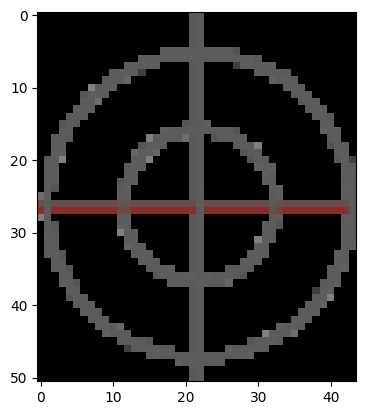

In [3]:
# Example of a cnn dataset cropped image

import matplotlib.pyplot as plt

plt.imshow(plt.imread("/content/drive/My Drive/cnn_dataset/cabinet/0488-0019_mask50.png"))

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

def train_cnn(dataset_path, num_classes, num_epochs=5):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    dataset = datasets.ImageFolder(dataset_path, transform=transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    model = SimpleCNN(num_classes=num_classes)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f}")
    torch.save(model.state_dict(), "cnn_classifier.pth")
    return model, dataset.classes

In [ ]:
image_dirs = [
    Path("/content/drive/My Drive/data/cad/images/train-00"),
    Path("/content/drive/My Drive/data/cad/images/train-01")
]

annotation_paths = [
    "/content/drive/My Drive/data/annotations/train-00-annotations.json",
    "/content/drive/My Drive/data/annotations/train-01-annotations.json"
]

output_dir = "/content/drive/My Drive/cnn_dataset"  # Folder where cropped masks will be saved


In [ ]:
anns_dict, category_map = load_annotations(annotation_paths)

for img_dir in image_dirs:
    generate_cnn_dataset(img_dir, anns_dict, category_map, output_dir)

Processing train-01: 100%|██████████| 5295/5295 [1:22:32<00:00,  1.07it/s]


In [ ]:
model, class_names = train_cnn("/content/drive/My Drive/cnn_dataset", num_classes=len(category_map), num_epochs=10)

Epoch 1/10 - Loss: 1124.9883
Epoch 2/10 - Loss: 480.8304
Epoch 3/10 - Loss: 290.0186
Epoch 4/10 - Loss: 212.3643
Epoch 5/10 - Loss: 180.8855
Epoch 6/10 - Loss: 149.2999
Epoch 7/10 - Loss: 145.2624
Epoch 8/10 - Loss: 128.2357
Epoch 9/10 - Loss: 117.8866
Epoch 10/10 - Loss: 114.0398


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/cnn_dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Get class names from generator
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())


Found 33306 images belonging to 25 classes.


In [ ]:

class_names

['airconditioner',
 'bath',
 'bath tub',
 'bed',
 'cabinet',
 'chair',
 'double door',
 'elevator',
 'gas stove',
 'opening symbol',
 'refrigerator',
 'single door',
 'sink',
 'sliding door',
 'sliding window',
 'sofa',
 'squat toilet',
 'stair',
 'table',
 'toilet',
 'tv cabinet',
 'urinal',
 'wardrobe',
 'washing machine',
 'window']

In [ ]:
import torch.nn.functional as F
import matplotlib.patches as patches

def predict_segment_crops(image_path, model, class_names, threshold=0.5):
    '''
    Function to predict the segment crops from the image.
    '''
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(image)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    predictions = []

    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image)

    model.eval()
    for m in masks:
        x, y, w, h = m['bbox']
        crop = image[y:y+h, x:x+w]
        input_tensor = transform(Image.fromarray(crop)).unsqueeze(0)

        with torch.no_grad():
            out = model(input_tensor)
            probs = F.softmax(out, dim=1)
            conf, pred = torch.max(probs, dim=1)
            conf = conf.item()
            pred = pred.item()

        if conf >= threshold:
            label = class_names[pred]
            predictions.append({"bbox": [x, y, w, h], "label": label, "confidence": conf})

            # Visualization
            vis_label = f"{label} ({conf:.2f})"
            print(f"Detected: {vis_label} at bbox {x, y, w, h}")
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 5, vis_label, color='white', fontsize=10, bbox=dict(facecolor='green', alpha=0.6))

    plt.axis('off')
    plt.show()

    return predictions


Detected: bed (1.00) at bbox (443, 456, 205, 97)
Detected: bed (1.00) at bbox (442, 295, 206, 99)
Detected: bed (0.99) at bbox (210, 294, 207, 100)
Detected: window (1.00) at bbox (159, 194, 181, 21)
Detected: chair (0.98) at bbox (0, 293, 47, 58)
Detected: chair (1.00) at bbox (92, 293, 54, 58)
Detected: chair (0.99) at bbox (812, 292, 54, 59)
Detected: window (1.00) at bbox (879, 194, 120, 21)
Detected: wardrobe (1.00) at bbox (441, 626, 206, 103)
Detected: bed (1.00) at bbox (442, 295, 207, 157)
Detected: stair (0.97) at bbox (442, 295, 207, 254)
Detected: chair (1.00) at bbox (713, 292, 56, 59)
Detected: window (1.00) at bbox (440, 194, 180, 21)
Detected: sink (1.00) at bbox (553, 864, 81, 50)
Detected: chair (0.99) at bbox (457, 312, 40, 65)
Detected: chair (0.95) at bbox (457, 472, 41, 65)
Detected: toilet (1.00) at bbox (322, 840, 55, 73)
Detected: stair (1.00) at bbox (221, 295, 428, 155)
Detected: toilet (1.00) at bbox (482, 840, 55, 73)
Detected: chair (0.99) at bbox (362, 31

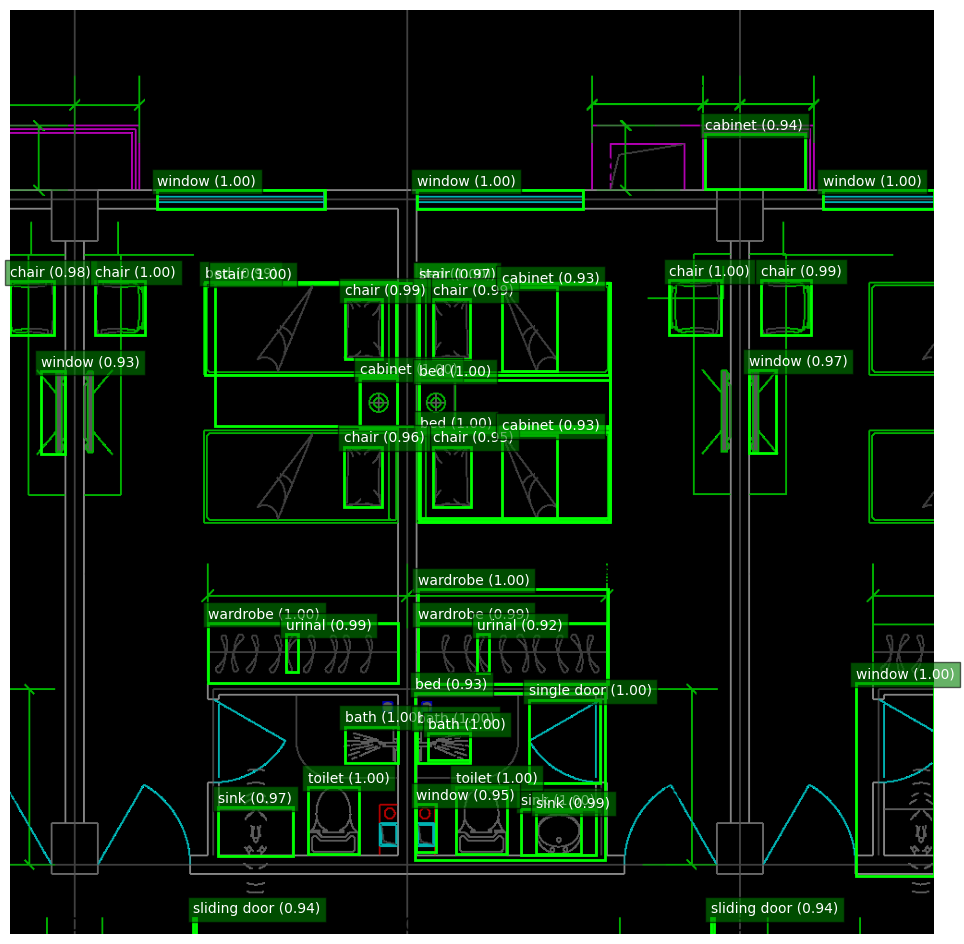

[{'bbox': [443, 456, 205, 97],
  'label': 'bed',
  'confidence': 0.9971176385879517},
 {'bbox': [442, 295, 206, 99],
  'label': 'bed',
  'confidence': 0.9981778860092163},
 {'bbox': [210, 294, 207, 100],
  'label': 'bed',
  'confidence': 0.9948714971542358},
 {'bbox': [159, 194, 181, 21],
  'label': 'window',
  'confidence': 0.9999998807907104},
 {'bbox': [0, 293, 47, 58],
  'label': 'chair',
  'confidence': 0.9839444756507874},
 {'bbox': [92, 293, 54, 58],
  'label': 'chair',
  'confidence': 0.996249258518219},
 {'bbox': [812, 292, 54, 59],
  'label': 'chair',
  'confidence': 0.9876178503036499},
 {'bbox': [879, 194, 120, 21],
  'label': 'window',
  'confidence': 0.9999959468841553},
 {'bbox': [441, 626, 206, 103],
  'label': 'wardrobe',
  'confidence': 0.99982750415802},
 {'bbox': [442, 295, 207, 157],
  'label': 'bed',
  'confidence': 0.9981405735015869},
 {'bbox': [442, 295, 207, 254],
  'label': 'stair',
  'confidence': 0.9701905250549316},
 {'bbox': [713, 292, 56, 59],
  'label':

In [ ]:
predict_segment_crops('/content/drive/My Drive/data/cad/images/train-00/0000-0002.png',model,class_names=class_names,threshold=0.9)

In [ ]:
def get_ground_truth_for_image(gt_data, filename):
    '''
    Function to get the ground truth bounding box for the image.
    '''

    # Find the image id
    img_id = next(img['id'] for img in gt_data['images'] if img['file_name'] == filename)

    # Get annotations for this image
    annots = [ann for ann in gt_data['annotations'] if ann['image_id'] == img_id]

    ground_truth = []
    for ann in annots:
        box = ann['bbox']  # format: [x, y, w, h]
        label_id = ann['category_id']
        label = category_map[label_id]
        ground_truth.append({'bbox': box, 'label': label})

    return ground_truth


In [ ]:
def evaluate_predictions(predictions, ground_truth, iou_threshold=0.5):
    '''
    Get the precision and recall for the predictions.
    '''
    matched_gt = set()
    tp = 0
    fp = 0

    for pred in predictions:
        pred_box = pred["bbox"]
        pred_label = pred["label"]
        best_iou = 0
        best_gt_idx = -1

        for i, gt in enumerate(ground_truth):
            if i in matched_gt:
                continue
            gt_box = gt["bbox"]
            gt_label = gt["label"]
            iou_score = iou(pred_box, gt_box)

            if iou_score > best_iou:
                best_iou = iou_score
                best_gt_idx = i

        if best_iou >= iou_threshold and pred_label == ground_truth[best_gt_idx]["label"]:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1

    fn = len(ground_truth) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

    return precision, recall, tp, fp, fn


In [ ]:
import json

with open("/content/drive/My Drive/data/annotations/test-00-annotations.json") as f:
    gt_data = json.load(f)


In [ ]:
total_tp = total_fp = total_fn = 0
num_images = 0

for img_meta in gt_data['images'][:50]:
    filename = img_meta['file_name']
    image_path = f"/content/drive/My Drive/data/cad/images/test-00/{filename}"

    try:
        ground_truth = get_ground_truth_for_image(gt_data, filename)
        if not ground_truth:
            continue

        predictions = predict_segment_crops(image_path, model, class_names, threshold=0.9)
        precision, recall, tp, fp, fn = evaluate_predictions(predictions, ground_truth)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        num_images += 1

        print(f"{filename}: Precision={precision:.2f}, Recall={recall:.2f}, TP={tp}, FP={fp}, FN={fn}")

    except Exception as e:
        print(f"Skipping {filename}: {e}")

# Final metrics
avg_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
avg_recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

print(f"\nAverage over {num_images} images:")
print(f"Precision: {avg_precision:.2f}")
print(f"Recall: {avg_recall:.2f}")


Output hidden; open in https://colab.research.google.com to view.

# Generate predictions

In [ ]:
num_classes = len(class_names)
model = SimpleCNN(num_classes=27)

# Load weights
model.load_state_dict(torch.load("cnn_classifier.pth"))
model.eval()  # Set to evaluation mode


SimpleCNN(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=100352, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=27, bias=True)
  )
)

Detected: single door (0.61) at bbox (0, 908, 223, 91)
Detected: cabinet (0.96) at bbox (322, 12, 122, 40)
Detected: airconditioner (1.00) at bbox (236, 810, 56, 57)
Detected: sofa (0.85) at bbox (0, 551, 53, 299)
Detected: table (0.61) at bbox (941, 0, 58, 42)
Detected: washing machine (0.99) at bbox (557, 776, 60, 61)
Detected: single door (0.51) at bbox (572, 0, 163, 78)
Detected: sofa (0.96) at bbox (134, 761, 79, 86)
Detected: table (1.00) at bbox (101, 645, 66, 101)
Detected: bed (1.00) at bbox (405, 492, 211, 262)
Detected: squat toilet (0.87) at bbox (42, 78, 35, 36)
Detected: sofa (0.93) at bbox (134, 544, 79, 85)
Detected: refrigerator (1.00) at bbox (328, 350, 70, 57)
Detected: window (0.99) at bbox (388, 861, 160, 42)
Detected: table (0.98) at bbox (28, 329, 80, 137)
Detected: sofa (0.93) at bbox (134, 544, 80, 125)
Detected: gas stove (1.00) at bbox (425, 185, 77, 48)
Detected: sink (0.82) at bbox (781, 638, 103, 103)
Detected: cabinet (0.77) at bbox (0, 909, 26, 90)
Detec

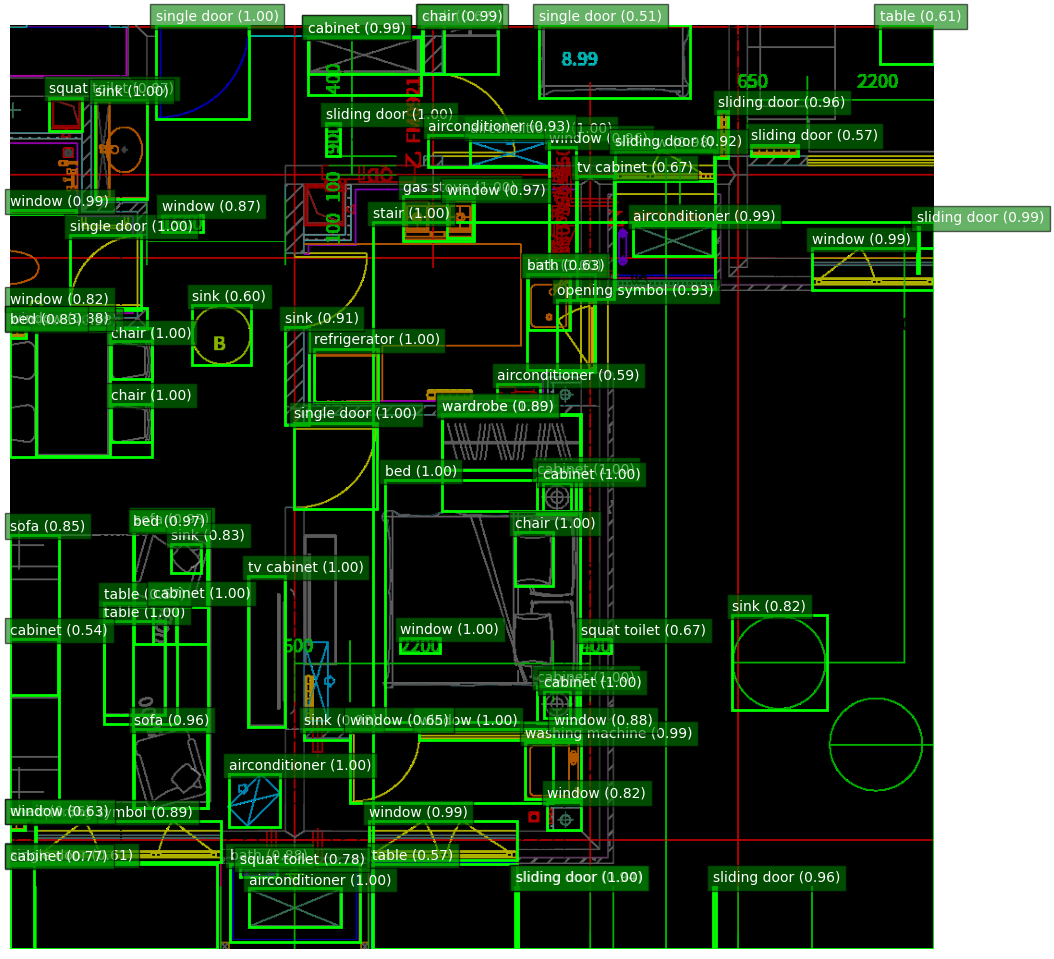

[{'bbox': [0, 908, 223, 91],
  'label': 'single door',
  'confidence': 0.6123359799385071},
 {'bbox': [322, 12, 122, 40],
  'label': 'cabinet',
  'confidence': 0.9637001752853394},
 {'bbox': [236, 810, 56, 57],
  'label': 'airconditioner',
  'confidence': 0.9998589754104614},
 {'bbox': [0, 551, 53, 299],
  'label': 'sofa',
  'confidence': 0.8518561124801636},
 {'bbox': [941, 0, 58, 42],
  'label': 'table',
  'confidence': 0.6085185408592224},
 {'bbox': [557, 776, 60, 61],
  'label': 'washing machine',
  'confidence': 0.9869490265846252},
 {'bbox': [572, 0, 163, 78],
  'label': 'single door',
  'confidence': 0.5142168402671814},
 {'bbox': [134, 761, 79, 86],
  'label': 'sofa',
  'confidence': 0.9639076590538025},
 {'bbox': [101, 645, 66, 101],
  'label': 'table',
  'confidence': 0.9990859031677246},
 {'bbox': [405, 492, 211, 262],
  'label': 'bed',
  'confidence': 0.999852180480957},
 {'bbox': [42, 78, 35, 36],
  'label': 'squat toilet',
  'confidence': 0.8690085411071777},
 {'bbox': [1

In [ ]:
predict_segment_crops('/content/drive/My Drive/data/cad/images/train-01/0001-0040.png',model,class_names=class_names,threshold=0.5)